In [13]:
import requests
import h5py
import matplotlib.pyplot as plt
import numpy as np
import scipy.linalg as sci

In [3]:
baseUrl = 'http://www.tng-project.org/api/'
headers = {"api-key":"e7205be31fb9f9b069960f52cf1481c1"}

In [4]:
h=0.6774
sn,scales,zs=np.loadtxt("redshifts.dat",unpack=True)

In [5]:
def factors(snap):
   a=scales[snap]
   aa=np.sqrt(a)
   redshift=zs[snap]
   scalefactor=1./(1+redshift)
   kpc=scalefactor/h
   return aa, kpc

In [6]:
def get(path, params=None):
    # make HTTP GET request to path
    r = requests.get(path, params=params, headers=headers)

    # raise exception if response code is not HTTP SUCCESS (200)
    r.raise_for_status()

    if r.headers['content-type'] == 'application/json':
        return r.json() # parse json responses automatically

    if 'content-disposition' in r.headers:
        filename = r.headers['content-disposition'].split("filename=")[1]
        with open(filename, 'wb') as f:
            f.write(r.content)
        return filename # return the filename string

    return r

In [16]:
def download(subid,snapnum,nameid):
    aa,kpc=factors(snapnum)

    url = "http://www.tng-project.org/api/TNG50-1/snapshots/"+str(snapnum)+"/subhalos/"+str(subid)
    sub=get(url)

    if sub['len_stars']>0:
       cutout_stars={'stars':'Coordinates,Masses,Velocities,GFM_StellarFormationTime,ParticleIDs'}    
       stars=get(url+"/cutout.hdf5",cutout_stars)    
       with h5py.File(stars,'r+') as f:
           x = f['PartType4']['Coordinates'][:,0] - sub['pos_x']
           y = f['PartType4']['Coordinates'][:,1] - sub['pos_y']
           z = f['PartType4']['Coordinates'][:,2] - sub['pos_z']
           masses=f['PartType4']['Masses'][:]
           vx = aa*f['PartType4']['Velocities'][:,0] - sub['vel_x']
           vy = aa*f['PartType4']['Velocities'][:,1] - sub['vel_y']
           vz = aa*f['PartType4']['Velocities'][:,2] - sub['vel_z']
           t=f['PartType4']['GFM_StellarFormationTime'][:]
       outdat=np.transpose((masses/h,x*kpc,y*kpc,z*kpc,vx,vy,vz,t))
       np.savetxt('discs/stars_'+str(nameid)+'_snap_'+str(snapnum)+'.txt', outdat)
       return outdat

In [11]:
snapnum = 99
subid = 546474
nameid = 546474

In [19]:
download(subid,snapnum,nameid)

array([[ 3.96512041e-06,  8.65476046e-02, -6.59075853e-02, ...,
         1.30583856e+00, -1.47623559e+01,  2.89999962e-01],
       [ 8.12939288e-06,  9.76072972e-02, -5.57940204e-02, ...,
         1.57671346e+01, -3.53247911e+01,  3.06935847e-01],
       [ 4.75015440e-06,  7.99334616e-02, -1.36257992e-01, ...,
         3.60450647e+00, -1.81326333e+01,  4.97021019e-01],
       ...,
       [ 4.06164872e-06, -2.95589563e+02, -9.45985328e+01, ...,
        -2.70742655e+01,  5.74236258e+01,  1.36036932e-01],
       [ 6.14089231e-06, -3.09338576e+02, -7.16492047e+01, ...,
        -2.33892374e+01,  7.09599570e+01,  3.55217576e-01],
       [ 6.69467317e-06, -3.13341970e+02, -6.02519503e+01, ...,
        -3.37263193e+01,  7.39499167e+01,  1.42722443e-01]],
      shape=(792205, 8))

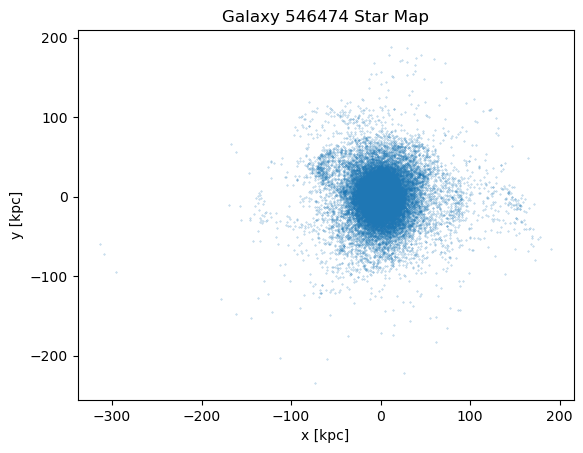

In [27]:
data = np.loadtxt('discs/stars_'+str(nameid)+'_snap_'+str(snapnum)+'.txt')
x = data[:, 1]
y = data[:, 2]

plt.scatter(x, y, s=0.1, alpha=0.5) # s=0.1 makes the points small so you can see the shape
plt.xlabel('x [kpc]')
plt.ylabel('y [kpc]')
plt.title(f'Galaxy {nameid} Star Map')
plt.show()

In [14]:
#quasi shrinking sphere algorithm to center galaxies in TNG (for first use of shrinking sphere see Power+2003)
#set of parameters that works ok RS=half mass radius for stars from TNG catalogues
#Rbig=5*RS
#Rsmall=.25*RS
#dR=(Rbig-Rsmall)/20
#Rvel=RS
def cent1(m,x,y,z,Rbig,dR,Rsmall,vx,vy,vz,Rvel):
    xc0=0.
    yc0=0.
    zc0=0.

    R=Rbig
    xc1=xc0
    yc1=yc0
    zc1=zc0

    while R>=Rsmall:
        xin=[]
        yin=[]
        zin=[]
        mins=[]
        for i in range(len(x)):
            r=np.sqrt((x[i]-xc1)**2+(y[i]-yc1)**2+(z[i]-zc1)**2)  
            if r<=R:
                xin.append(x[i])
                yin.append(y[i])
                zin.append(z[i])
                mins.append(m[i])
        xc1=np.average(xin,weights=mins)
        yc1=np.average(yin,weights=mins)
        zc1=np.average(zin,weights=mins)
        R=R-dR

    vxin=[]
    vyin=[]
    vzin=[]
    mvel=[]
    for i in range(len(x)):
        r=np.sqrt((x[i]-xc1)**2+(y[i]-yc1)**2+(z[i]-zc1)**2)
        if r<=Rvel:
            vxin.append(vx[i])
            vyin.append(vy[i])
            vzin.append(vz[i])
            mvel.append(m[i])

    vxc=np.average(vxin,weights=mvel)
    vyc=np.average(vyin,weights=mvel)
    vzc=np.average(vzin,weights=mvel)
    return xc1,yc1,zc1,vxc,vyc,vzc

In [28]:
RS = 2.5555
Rbig=5*RS
Rsmall=.25*RS
dR=(Rbig-Rsmall)/20
Rvel=RS

In [29]:
#function to get rotation matrix
#to be called 
def get_rotation_matrix(i_v, unit=None):
    # From http://www.j3d.org/matrix_faq/matrfaq_latest.html#Q38
    if unit is None:
        unit = [1.0, 0.0, 0.0]
    # Normalize vector length
    i_v /= np.linalg.norm(i_v)

    # Get axis
    uvw = np.cross(i_v, unit)

    # compute trig values - no need to go through arccos and back
    rcos = np.dot(i_v, unit)
    rsin = np.linalg.norm(uvw)

    #normalize and unpack axis
    if not np.isclose(rsin, 0):
        uvw /= rsin
    u, v, w = uvw

    # Compute rotation matrix - re-expressed to show structure
    return (
        rcos * np.eye(3) +
        rsin * np.array([
            [ 0, -w,  v],
            [ w,  0, -u],
            [-v,  u,  0]
        ]) +
        (1.0 - rcos) * uvw[:,None] * uvw[None,:]
    )

In [31]:
data = np.loadtxt('discs/stars_'+str(nameid)+'_snap_'+str(snapnum)+'.txt')
m = data[:, 0]
x = data[:, 1]
y = data[:, 2]
z = data[:, 3]
vx = data[:, 4]
vy = data[:, 5]
vz = data[:, 6]
t = data[:, 7]

new_coord = cent1(m,x,y,z,Rbig,dR,Rsmall,vx,vy,vz,Rvel)


-0.005847818385323527


In [32]:
print(new_coord[0])

-0.005847818385323527


In [37]:
x_new = x-new_coord[0]
y_new = x-new_coord[1]
z_new = x-new_coord[2]
vx_new = x-new_coord[3]
vy_new = x-new_coord[4]
vz_new = x-new_coord[5]

outdat_centered=np.transpose((data[:, 0],x_new,y_new,z_new,vx_new,vy_new,vz_new,data[:, 7]))
np.savetxt('discs/stars_'+str(nameid)+'_snap_'+str(snapnum)+"_centered"+'.txt', outdat_centered)


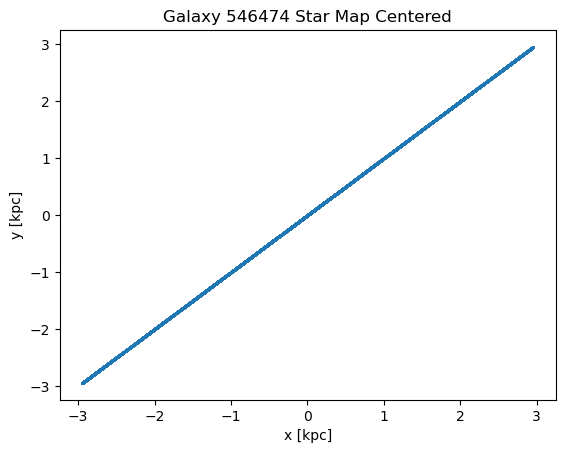

In [46]:
data_centered = np.loadtxt('discs/stars_'+str(nameid)+'_snap_'+str(snapnum)+"_centered"+'.txt')
m = data_centered[:, 0]
x = data_centered[:, 1]
y = data_centered[:, 2]
z = data_centered[:, 3]
vx = data_centered[:, 4]
vy = data_centered[:, 5]
vz = data_centered[:, 6]
t = data_centered[:, 7]

# Calculate 3D distance for all stars at once
dist = np.sqrt(x**2 + y**2 + z**2)

# Create a filter (mask)
mask = dist < (2 * RS)

# Apply the filter
m_cut = m[mask]
x_cut = x[mask]
y_cut = y[mask]
z_cut = z[mask]
vx_cut = vx[mask]
vy_cut = vy[mask]
vz_cut = vz[mask]
t_cut = t[mask]

plt.scatter(x_cut, y_cut, s=0.1, alpha=0.5) # s=0.1 makes the points small so you can see the shape
plt.xlabel('x [kpc]')
plt.ylabel('y [kpc]')
plt.title(f'Galaxy {nameid} Star Map Centered')
plt.show()

In [49]:
lists = [m_cut, x_cut, y_cut, z_cut, vx_cut, vy_cut, vz_cut, t_cut]
for i, lst in enumerate(lists):
    print(f"List {i} length: {len(lst)}")

List 0 length: 581950
List 1 length: 581950
List 2 length: 581950
List 3 length: 581950
List 4 length: 581950
List 5 length: 581950
List 6 length: 581950
List 7 length: 581950


In [50]:
outdat_2RS=np.transpose((m_cut,x_cut,y_cut,z_cut,vx_cut,vy_cut,vz_cut,t_cut))
np.savetxt('discs/stars_'+str(nameid)+'_snap_'+str(snapnum)+"_2RS"+'.txt', outdat_2RS)